In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    """Represents a state in the conversation graph."""

    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

c:\Users\admin\Desktop\Projects\AI_ML_DATASCIENCE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
## Node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

# add nodes and edges to the graph
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

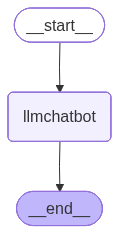

In [8]:
graph

In [9]:
response = graph.invoke({"messages": "Hello, how are you?"})

In [10]:
response

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='8f07e958-4902-4b92-8721-118c660db33c'),
  AIMessage(content="I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help you with any questions or information you need. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 41, 'total_tokens': 93, 'completion_time': 0.058031665, 'completion_tokens_details': None, 'prompt_time': 0.002000229, 'prompt_tokens_details': None, 'queue_time': 0.047892478, 'total_time': 0.060031894}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb6d4-36a5-7913-93d8-b8bfcde0dd1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41

In [11]:
response["messages"][-1].content

"I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help you with any questions or information you need. How can I assist you today?"

In [12]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thank you for asking. Is there something specific you'd like to know or discuss? I can assist you with information and provide answers to your questions.


## Langgraph with tools


In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

### Custom tool


In [14]:
def multiply(a: int, b: int) -> int:
    """Multiplies a and b"""
    return a * b

In [15]:
tools=[tool, multiply]
tools

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

In [16]:
llm_with_tools=llm.bind_tools(tools)

In [17]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000248117AC500>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024811B23DA0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when 

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools_condtion routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


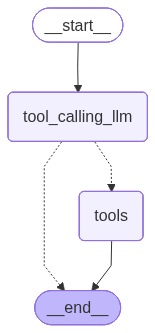

In [19]:
graph=builder.compile()
graph

In [20]:
response = graph.invoke({"messages":"What is the recent ai news"})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=tavily_search>{"query": "recent ai news", "topic": "news", "time_range": "day", "search_depth": "advanced"}<function=tavily_search>{"query": "ai news", "topic": "news", "time_range": "day", "search_depth": "basic"}'}}

In [ ]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/ai-companies-raising-prices-internal-token-limits-openai-anthropic-ipo-2026-6", "title": "The All-You-Can-Eat AI Era Is Over. It\'s Time to Count Calories. - Business Insider", "score": 0.6929958, "published_date": "Wed, 10 Jun 2026 09:19:01 GMT", "content": "That calculus has some executives angling for cheaper AI. Some companies Business Insider spoke to, including Coinbase, have begun offloading basic work to less advanced AI models, either from American companies or from Chinese firms like Deepseek and MiniMax.\\n\\nAhmad Awais, the founder of the coding agent startup Command Code, told Business Insider his company gained 10,000 customers in a recent 30-day stretch, largely driven by demand for cheaper models.\\n\\nFor some of those businesses, using the most advanced — and expensive — models isn\'t worth it for everything. Stuart, the Harness

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (82jgzfnj0)
 Call ID: 82jgzfnj0
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/ai-companies-raising-prices-internal-token-limits-openai-anthropic-ipo-2026-6", "title": "The All-You-Can-Eat AI Era Is Over. It's Time to Count Calories. - Business Insider", "score": 0.6929958, "published_date": "Wed, 10 Jun 2026 09:19:01 GMT", "content": "That calculus has some executives angling for cheaper AI. Some companies Business Insider spoke to, including Coinbase, have begun offloading basic work

In [ ]:
response = graph.invoke({"messages":"What is 2 multiply by 3?"})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (jphbpgcwj)
 Call ID: jphbpgcwj
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [ ]:
response = graph.invoke({"messages":"What is 2 multiply by 3 and then multipy by 10"})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and then multipy by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (xb46zcggc)
 Call ID: xb46zcggc
  Args:
    a: 2
    b: 3
  multiply (4wf3s7m9y)
 Call ID: 4wf3s7m9y
  Args:
    a: 6
    b: 10
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

60


## ReAct Agent Architecture

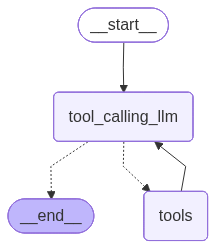

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tools", END)

graph = builder.compile()
graph

In [ ]:
response = graph.invoke({"messages":"What is 2 multiply by 3 and then give me latest news."})

In [ ]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and then give me latest news.
================================== Ai Message ==================================
Tool Calls:
  multiply (7y5k4p78a)
 Call ID: 7y5k4p78a
  Args:
    a: 2
    b: 3
  tavily_search (ng45w9crc)
 Call ID: ng45w9crc
  Args:
    include_images: None
    query: latest news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.news8000.com/news/youth-workforce-center-partners-revealed/video_36000e51-c800-57b8-93f9-d9b97449795e.html", "title": "Youth workforce center partners revealed - news8000.com", "score": 0.40867847, "published_date": "Wed

## Adding Memory In Agentic Graph

In [21]:
response = graph.invoke({"messages":"Hello my name is Vraj."})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Vraj.
================================== Ai Message ==================================

Nice to meet you, Vraj. Is there anything I can help you with or would you like to chat?


In [22]:
response = graph.invoke({"messages":"What is my name?"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to know or recall any information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I can try to have a more personalized conversation with you!


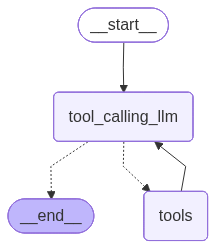

In [23]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node definition 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tools", END)

graph = builder.compile(checkpointer=memory)
graph

In [24]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Vraj."}, config=config)

response

{'messages': [HumanMessage(content='Hi my name is Vraj.', additional_kwargs={}, response_metadata={}, id='01062bf4-5025-4f9a-8861-c69fb2d4eace'),
  AIMessage(content="Nice to meet you, Vraj. What brings you here today? Do you have any questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1744, 'total_tokens': 1772, 'completion_time': 0.070432299, 'completion_tokens_details': None, 'prompt_time': 0.351646017, 'prompt_tokens_details': None, 'queue_time': 0.219933686, 'total_time': 0.422078316}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb6e4-cf04-7b12-b42f-a78d1e3196bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1744, 'output_tokens': 28, 'total_tokens': 1772})]}

In [25]:
response["messages"][-1].content

"Nice to meet you, Vraj. What brings you here today? Do you have any questions or topics you'd like to discuss?"

In [27]:
response=graph.invoke({"messages":"Do you remember my name?"}, config=config)

response["messages"][-1].content

'Yes, your name is Vraj.'